# 03 - EDA, features causais e divisao temporal

**Objetivo:** transformar a base mestra em um conjunto de modelagem sem vazamento temporal.

Criamos:
- historico do nivel;
- acumulados de chuva;
- niveis a montante;
- alvos para 1 h, 2 h e 4 h;
- treino, validacao, teste 2024 e holdout 2025.

### Saidas
- `features_causal.parquet`
- `feature_dictionary.csv/html`
- `split_counts.csv/html`
- figuras das distribuicoes e da linha do tempo.

In [12]:
from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------------
# Localiza a raiz do projeto e o dataset de forma robusta.
# Funciona se o notebook estiver em Field-Project/notebooks.
# ------------------------------------------------------------------
CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

RAW_PARENT = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"

OUTPUTS = ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
PREDICTIONS = OUTPUTS / "predictions"

for p in [INTERIM, PROCESSED, MODELS, FIGURES, TABLES, PREDICTIONS]:
    p.mkdir(parents=True, exist_ok=True)

def find_dataset_root(raw_parent: Path) -> Path:
    """Procura uma pasta que contenha Data/SHP e Data/Telemetric_Time_Series."""
    candidates = [raw_parent] + [p for p in raw_parent.rglob("*") if p.is_dir()]
    for p in candidates:
        data = p / "Data"
        if (data / "SHP").exists() and (data / "Telemetric_Time_Series").exists():
            return p
    raise FileNotFoundError(
        "Nao encontrei o dataset. Extraia o .rar dentro de data/raw/ "
        "mantendo a pasta Data/ com SHP/, Radar/ e Telemetric_Time_Series/."
    )

RAW = find_dataset_root(RAW_PARENT)
DATA = RAW / "Data"
SHP = DATA / "SHP"
TELE = DATA / "Telemetric_Time_Series"
RADAR = DATA / "Radar"

print("ROOT:", ROOT)
print("Dataset:", RAW)

ROOT: C:\Users\osmar\Área de Trabalho\Field-Project
Dataset: C:\Users\osmar\Área de Trabalho\Field-Project\data\raw\TTI-HydroMet_Dataset_version2


In [13]:
def save_table(df, stem, preview_rows=15, sort_by=None, ascending=True):
    """
    Salva a tabela completa em CSV e HTML e mostra apenas uma amostra no notebook.
    Isso evita outputs gigantes e facilita abrir a tabela fora do Jupyter.
    """
    z = df.copy()
    if sort_by is not None and sort_by in z.columns:
        z = z.sort_values(sort_by, ascending=ascending)

    csv_path = TABLES / f"{stem}.csv"
    html_path = TABLES / f"{stem}.html"

    z.to_csv(csv_path, index=False)
    z.to_html(html_path, index=False)

    display(Markdown(
        f"**Tabela completa salva em:**  \n"
        f"- `{csv_path.relative_to(ROOT)}`  \n"
        f"- `{html_path.relative_to(ROOT)}`  \n"
        f"Mostrando apenas as primeiras {min(preview_rows, len(z))} linhas:"
    ))
    display(z.head(preview_rows))
    return z

def save_figure(fig, stem, dpi=220):
    """Salva uma figura em PNG e a mantem visivel no notebook."""
    path = FIGURES / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(Markdown(f"**Figura salva em:** `{path.relative_to(ROOT)}`"))
    return path

In [14]:
master = pd.read_parquet(PROCESSED / "master_base.parquet").sort_index()
stage = master["stage_413"].astype("float32")
print(master.shape)

(525744, 27)


**Tabela completa salva em:**  
- `outputs\tables\delta_h_summary.csv`  
- `outputs\tables\delta_h_summary.html`  
Mostrando apenas as primeiras 4 linhas:

,variavel,count,mean,std,min,1%,5%,50%,95%,99%,99.9%,max
0,delta_10m,510609.0,-0.000018,0.122679,-9.899048,-0.100037,-0.033020,0.000000,0.021973,0.140015,0.767412,9.910034
1,delta_60m,510338.0,-0.000003,0.278419,-10.066040,-0.583984,-0.182007,-0.010010,0.077026,0.881020,3.371680,9.953003
2,delta_120m,510105.0,0.000006,0.433440,-10.100037,-1.080017,-0.338989,-0.010986,0.151001,1.702964,4.551894,9.984009
3,delta_240m,509725.0,-0.000074,0.628794,-12.126038,-1.822021,-0.583008,-0.020020,0.372009,2.724741,5.341515,9.960999


**Figura salva em:** `outputs\figures\distribution_delta_120m.png`

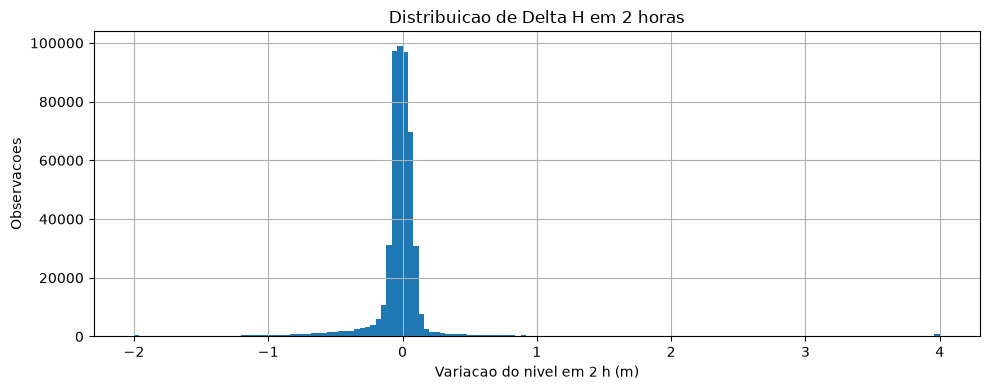

In [15]:
eda_delta = pd.DataFrame(index=master.index)
for horizon in [10, 60, 120, 240]:
    steps = horizon // 10
    eda_delta[f"delta_{horizon}m"] = stage.shift(-steps) - stage

summary = eda_delta.describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
).T.reset_index(names="variavel")
save_table(summary, "delta_h_summary", preview_rows=20)

fig, ax = plt.subplots(figsize=(10, 4))
eda_delta["delta_120m"].clip(-2, 4).hist(bins=150, ax=ax)
ax.set_xlabel("Variacao do nivel em 2 h (m)")
ax.set_ylabel("Observacoes")
ax.set_title("Distribuicao de Delta H em 2 horas")
plt.tight_layout()
save_figure(fig, "distribution_delta_120m")
plt.show()

In [16]:
blocks = []

D = {"stage_now": stage}
for k, label in [(1, "10m"), (3, "30m"), (6, "1h"), (12, "2h"), (18, "3h"), (36, "6h")]:
    D[f"stage_lag_{label}"] = stage.shift(k)
    D[f"stage_change_{label}"] = stage - stage.shift(k)

for w, label in [(6, "1h"), (18, "3h"), (36, "6h")]:
    rolling = stage.rolling(w, min_periods=max(2, int(0.8 * w)))
    D[f"stage_mean_{label}"] = rolling.mean()
    D[f"stage_min_{label}"] = rolling.min()
    D[f"stage_max_{label}"] = rolling.max()

stage_features = pd.DataFrame(D, index=master.index, dtype="float32")
assert stage_features.shape[1] == 22
blocks.append(stage_features)
print("Features de nivel:", stage_features.shape[1])

Features de nivel: 22


In [17]:
rain_cols_raw = [c for c in master.columns if c.startswith("rain_")]
assert len(rain_cols_raw) == 23

R = {}
for col in rain_cols_raw:
    s = master[col].astype("float32")
    R[col] = s
    for w, label in [(6, "1h"), (18, "3h"), (36, "6h"), (72, "12h")]:
        R[f"{col}_sum_{label}"] = s.rolling(
            w, min_periods=max(1, int(0.8 * w))
        ).sum()

rain_now = master[rain_cols_raw]
R["rain_basin_mean_now"] = rain_now.mean(axis=1)
R["rain_basin_max_now"] = rain_now.max(axis=1)
R["rain_gauges_available_now"] = rain_now.notna().sum(axis=1)
R["rain_gauges_wet_now"] = (rain_now.fillna(0) > 0).sum(axis=1)

mean_rain = rain_now.mean(axis=1)
for w, label in [(6, "1h"), (18, "3h"), (36, "6h"), (72, "12h")]:
    R[f"rain_basin_mean_sum_{label}"] = mean_rain.rolling(
        w, min_periods=max(1, int(0.8 * w))
    ).sum()

rain_features = pd.DataFrame(R, index=master.index, dtype="float32")
assert rain_features.shape[1] == 123
blocks.append(rain_features)
print("Features de chuva:", rain_features.shape[1])

Features de chuva: 123


In [18]:
U = {}
for sid in [1000490, 143, 283]:
    s = master[f"stage_{sid}"].astype("float32")
    U[f"up_{sid}_now"] = s
    for k, label in [(1, "10m"), (6, "1h"), (18, "3h")]:
        U[f"up_{sid}_lag_{label}"] = s.shift(k)
        U[f"up_{sid}_change_{label}"] = s - s.shift(k)

upstream_features = pd.DataFrame(U, index=master.index, dtype="float32")
assert upstream_features.shape[1] == 21
blocks.append(upstream_features)

features = pd.concat(blocks, axis=1)
assert features.shape[1] == 166
print("Total de features causais:", features.shape[1])

Total de features causais: 166


In [19]:
# Dicionario legivel das features.
def feature_group(name):
    if name.startswith("stage_"):
        return "nivel_413"
    if name.startswith("rain_"):
        return "chuva"
    if name.startswith("up_"):
        return "nivel_montante"
    return "outro"

feature_dictionary = pd.DataFrame({
    "feature": features.columns,
    "grupo": [feature_group(c) for c in features.columns],
})
save_table(feature_dictionary, "feature_dictionary", preview_rows=25)

**Tabela completa salva em:**  
- `outputs\tables\feature_dictionary.csv`  
- `outputs\tables\feature_dictionary.html`  
Mostrando apenas as primeiras 25 linhas:

,feature,grupo
0,stage_now,nivel_413
1,stage_lag_10m,nivel_413
2,stage_change_10m,nivel_413
3,stage_lag_30m,nivel_413
4,stage_change_30m,nivel_413
5,stage_lag_1h,nivel_413
6,stage_change_1h,nivel_413
7,stage_lag_2h,nivel_413
8,stage_change_2h,nivel_413
9,stage_lag_3h,nivel_413


,feature,grupo
0,stage_now,nivel_413
1,stage_lag_10m,nivel_413
2,stage_change_10m,nivel_413
3,stage_lag_30m,nivel_413
4,stage_change_30m,nivel_413
...,...,...
161,up_283_change_10m,nivel_montante
162,up_283_lag_1h,nivel_montante
163,up_283_change_1h,nivel_montante
164,up_283_lag_3h,nivel_montante


In [20]:
# Somente aqui usamos futuro: para construir os alvos historicos.
for horizon in [60, 120, 240]:
    steps = horizon // 10
    features[f"target_delta_{horizon}m"] = (stage.shift(-steps) - stage).astype("float32")
    features[f"target_stage_{horizon}m"] = stage.shift(-steps).astype("float32")

split = pd.Series("unused", index=features.index, dtype="object")
split.loc["2015-04-02 00:00":"2022-12-31 19:50"] = "train"
split.loc["2023-01-01 00:00":"2023-12-31 19:50"] = "validation"
split.loc["2024-01-01 00:00":"2024-12-31 19:50"] = "test_2024"
split.loc["2025-01-01 00:00":"2025-03-29 19:50"] = "blind_2025"
features["split"] = split

split_summary = (
    features["split"].value_counts()
    .rename_axis("split").reset_index(name="linhas")
)
save_table(split_summary, "split_overall_counts", preview_rows=10)

**Tabela completa salva em:**  
- `outputs\tables\split_overall_counts.csv`  
- `outputs\tables\split_overall_counts.html`  
Mostrando apenas as primeiras 5 linhas:

,split,linhas
0,train,407640
1,test_2024,52680
2,validation,52536
3,blind_2025,12648
4,unused,240


,split,linhas
0,train,407640
1,test_2024,52680
2,validation,52536
3,blind_2025,12648
4,unused,240


**Tabela completa salva em:**  
- `outputs\tables\split_counts.csv`  
- `outputs\tables\split_counts.html`  
Mostrando apenas as primeiras 12 linhas:

,horizon_min,split,n
0,60,train,406060
1,60,validation,45997
2,60,test_2024,46044
3,60,blind_2025,12027
4,120,train,405944
5,120,validation,45981
6,120,test_2024,45955
7,120,blind_2025,12021
8,240,train,405763
9,240,validation,45956


**Figura salva em:** `outputs\figures\split_timeline.png`

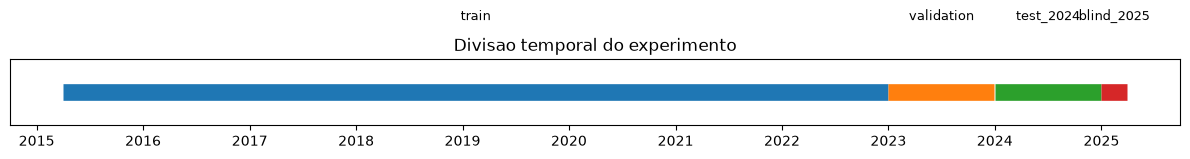

In [21]:
rows = []
for horizon in [60, 120, 240]:
    target = f"target_delta_{horizon}m"
    for split_name in ["train", "validation", "test_2024", "blind_2025"]:
        z = features[features["split"] == split_name]
        n = (z["stage_now"].notna() & z[target].notna()).sum()
        rows.append({"horizon_min": horizon, "split": split_name, "n": int(n)})

split_counts = pd.DataFrame(rows)
save_table(split_counts, "split_counts", preview_rows=20)

# Figura simples da divisao temporal.
fig, ax = plt.subplots(figsize=(12, 2.4))
segments = [
    ("train", pd.Timestamp("2015-04-02"), pd.Timestamp("2022-12-31")),
    ("validation", pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31")),
    ("test_2024", pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31")),
    ("blind_2025", pd.Timestamp("2025-01-01"), pd.Timestamp("2025-03-29")),
]
y = 0
for label, a, b in segments:
    ax.plot([a, b], [y, y], linewidth=12, solid_capstyle="butt")
    ax.text(a + (b-a)/2, y+0.12, label, ha="center", fontsize=9)
ax.set_yticks([])
ax.set_title("Divisao temporal do experimento")
plt.tight_layout()
save_figure(fig, "split_timeline")
plt.show()

In [22]:
features.to_parquet(PROCESSED / "features_causal.parquet")
print("Salvo:", (PROCESSED / "features_causal.parquet").relative_to(ROOT))

Salvo: data\processed\features_causal.parquet
